# Training Intensity Yesterday — Missingness Analysis

**Variable:** `Training Intensity Yesterday` — composite GPS load score `tanh(mean(TD%, HSD%, Dec%, Sprints%) / 100)`, range [0, 1).  
**Temporal position:** t-1 variable. It describes the session performed on the *previous* day. It is missing when the GPS benchmark percentages from Readiness\_Data1 were not recorded for that session.  

## Questions answered
1. How much is missing overall and when?
2. Was there actually a session on the day TI refers to?
3. Which activity types, medical statuses, and players drive the missingness?
4. How do match days and squad selection relate to TI availability?
5. What else is missing at the same time?
6. Do rows with missing TI look systematically different (wellness, ACWR)?

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
df = pd.read_excel(project_root / 'data' / 'processed' / 'RTT.xlsx',
                   parse_dates=['Date'])

# Convenience boolean masks
ti_valid   = df['Training Intensity Yesterday'].notna()
ti_missing = ~ti_valid
df['TI Status'] = np.where(ti_valid, 'Valid', 'Missing')

# Shifted DUM / DSG: the cycle position on the day the session occurred (t-1),
# not today's morning (t).  Needed whenever we relate TI to the match cycle.
df_s = df.sort_values(['Player ID', 'Date']).copy()
df_s['DUM_session'] = df_s.groupby('Player ID')['Days Until Match'].shift(1)
df_s['DSG_session'] = df_s.groupby('Player ID')['Days Since Game'].shift(1)

print(f'Loaded RTT.xlsx: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Players: {df["Player ID"].nunique()}, '
      f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'\nTraining Intensity Yesterday:')
print(f'  Valid:   {ti_valid.sum():,} rows ({100*ti_valid.mean():.1f}%)')
print(f'  Missing: {ti_missing.sum():,} rows ({100*ti_missing.mean():.1f}%)')

Loaded RTT.xlsx: 5,234 rows x 46 columns
Players: 28, Date range: 2025-07-27 to 2026-02-17

Training Intensity Yesterday:
  Valid:   3,237 rows (61.8%)
  Missing: 1,997 rows (38.2%)


## 2. Overall Missingness

38 % of all player-days have no Training Intensity score. The pie and seasonal bar below show the scale and timing.

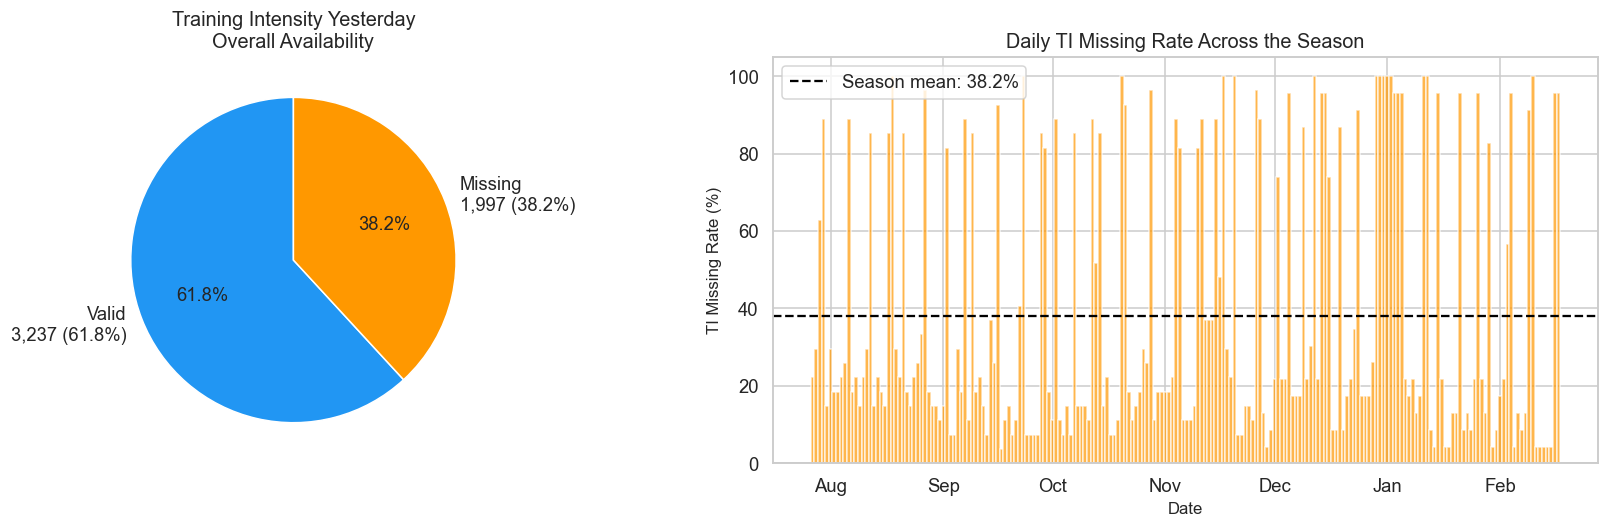

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie
ax = axes[0]
counts = [ti_valid.sum(), ti_missing.sum()]
labels = [f'Valid\n{ti_valid.sum():,} ({100*ti_valid.mean():.1f}%)',
          f'Missing\n{ti_missing.sum():,} ({100*ti_missing.mean():.1f}%)']
ax.pie(counts, labels=labels, colors=['#2196F3', '#FF9800'],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax.set_title('Training Intensity Yesterday\nOverall Availability')

# Daily missing rate across the season
ax = axes[1]
daily = df.groupby('Date')['TI Status'].apply(
    lambda x: (x == 'Missing').mean() * 100)
ax.bar(daily.index, daily.values, color='#FF9800', alpha=0.7, width=1)
ax.axhline(100 * ti_missing.mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Season mean: {100*ti_missing.mean():.1f}%')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlabel('Date')
ax.set_ylabel('TI Missing Rate (%)')
ax.set_title('Daily TI Missing Rate Across the Season')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Was There a Session on the Day TI Refers To?

`Training Intensity Yesterday` and `Activity Type Yesterday` both describe **day t-1** — the same calendar day. Comparing them is therefore temporally exact.

The dominant cause of missing TI is **no recorded activity type on day t-1** (Activity Type Yesterday = NaN). When an activity type IS recorded, TI is almost always present — the main exception is Rehab, where GPS benchmarks are not collected.

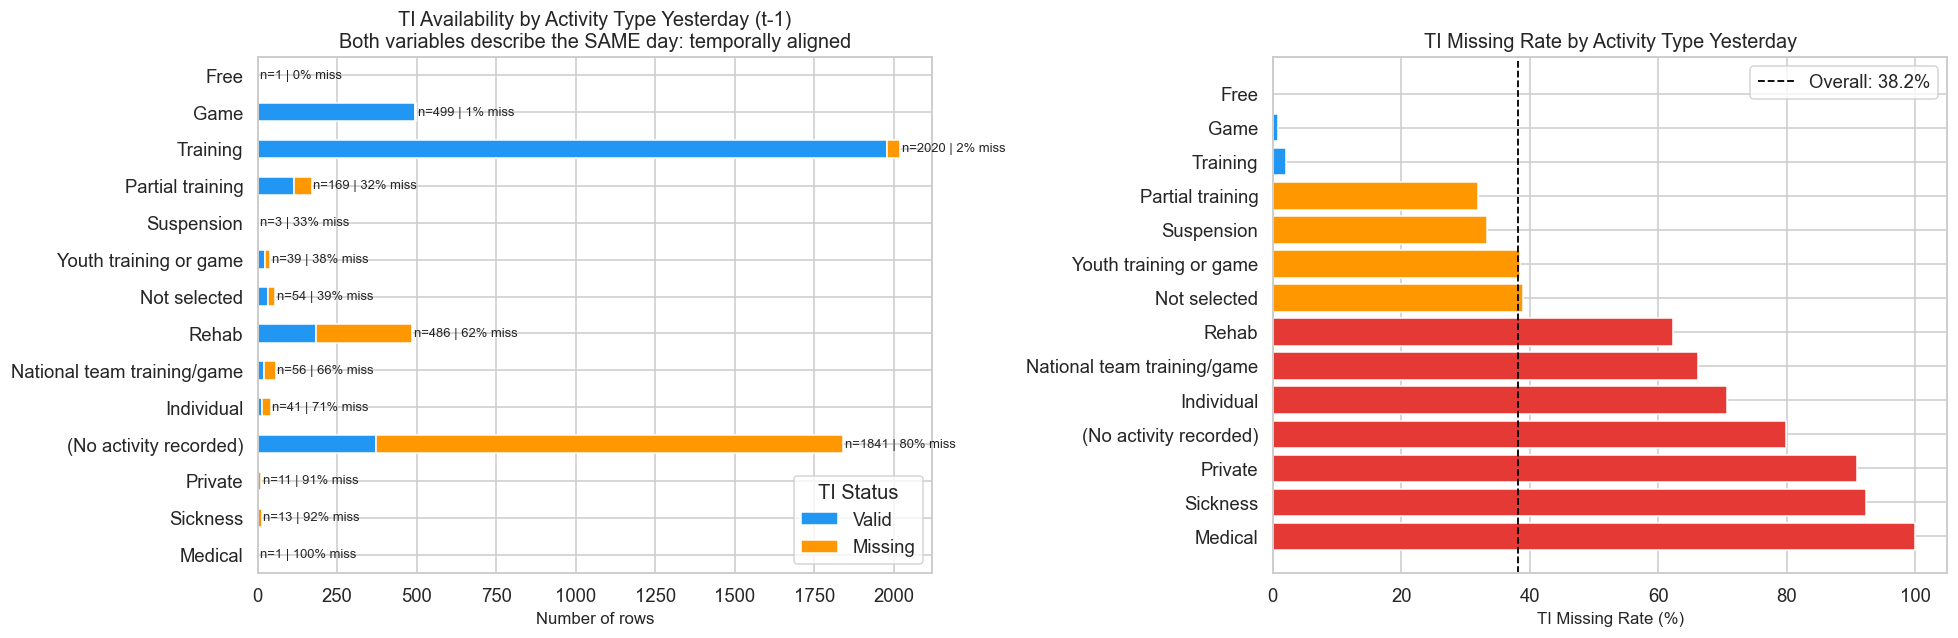

TI Status                    Valid  Missing  Total  Missing %
Activity Type Yesterday                                      
Medical                          0        1      1      100.0
Sickness                         1       12     13       92.3
Private                          1       10     11       90.9
(No activity recorded)         372     1469   1841       79.8
Individual                      12       29     41       70.7
National team training/game     19       37     56       66.1
Rehab                          183      303    486       62.3
Not selected                    33       21     54       38.9
Youth training or game          24       15     39       38.5
Suspension                       2        1      3       33.3
Partial training               115       54    169       32.0
Training                      1979       41   2020        2.0
Game                           495        4    499        0.8
Free                             1        0      1        0.0


In [3]:
ct = pd.crosstab(
    df['Activity Type Yesterday'].fillna('(No activity recorded)'),
    df['TI Status']
)
ct = ct[['Valid', 'Missing']]  # column order
ct['Total'] = ct.sum(axis=1)
ct['Missing %'] = (ct['Missing'] / ct['Total'] * 100).round(1)
ct = ct.sort_values('Missing %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Stacked bar: absolute counts
ax = axes[0]
ct[['Valid', 'Missing']].plot.barh(stacked=True, ax=ax,
                                    color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_xlabel('Number of rows')
ax.set_title('TI Availability by Activity Type Yesterday (t-1)\n'
             'Both variables describe the SAME day: temporally aligned')
ax.set_ylabel('')
for i, (idx_name, row) in enumerate(ct.iterrows()):
    ax.text(row['Total'] + 5, i, f'n={int(row["Total"])} | {row["Missing %"]:.0f}% miss',
            va='center', fontsize=8.5)

# Bar: Missing %
ax = axes[1]
colors = ['#E53935' if v > 50 else '#FF9800' if v > 10 else '#2196F3'
          for v in ct['Missing %']]
ax.barh(ct.index, ct['Missing %'], color=colors, edgecolor='white')
ax.axvline(100 * ti_missing.mean(), color='black', linestyle='--',
           linewidth=1.2, label=f'Overall: {100*ti_missing.mean():.1f}%')
ax.set_xlabel('TI Missing Rate (%)')
ax.set_title('TI Missing Rate by Activity Type Yesterday')
ax.legend()

plt.tight_layout()
plt.show()

print(ct.to_string())

## 4. What Was Happening on Days Where TI Is Missing?

Among the 1,600 rows with missing TI, we can ask two questions about the missing day:

- **Activity Type Yesterday** (t-1): what did the player do on the session day itself?
- **Activity Type Today** (post-assessment, t): what did the player do on the *following* day?

The first column is the direct answer. The second gives context on whether the player re-entered a normal training cycle the next day.

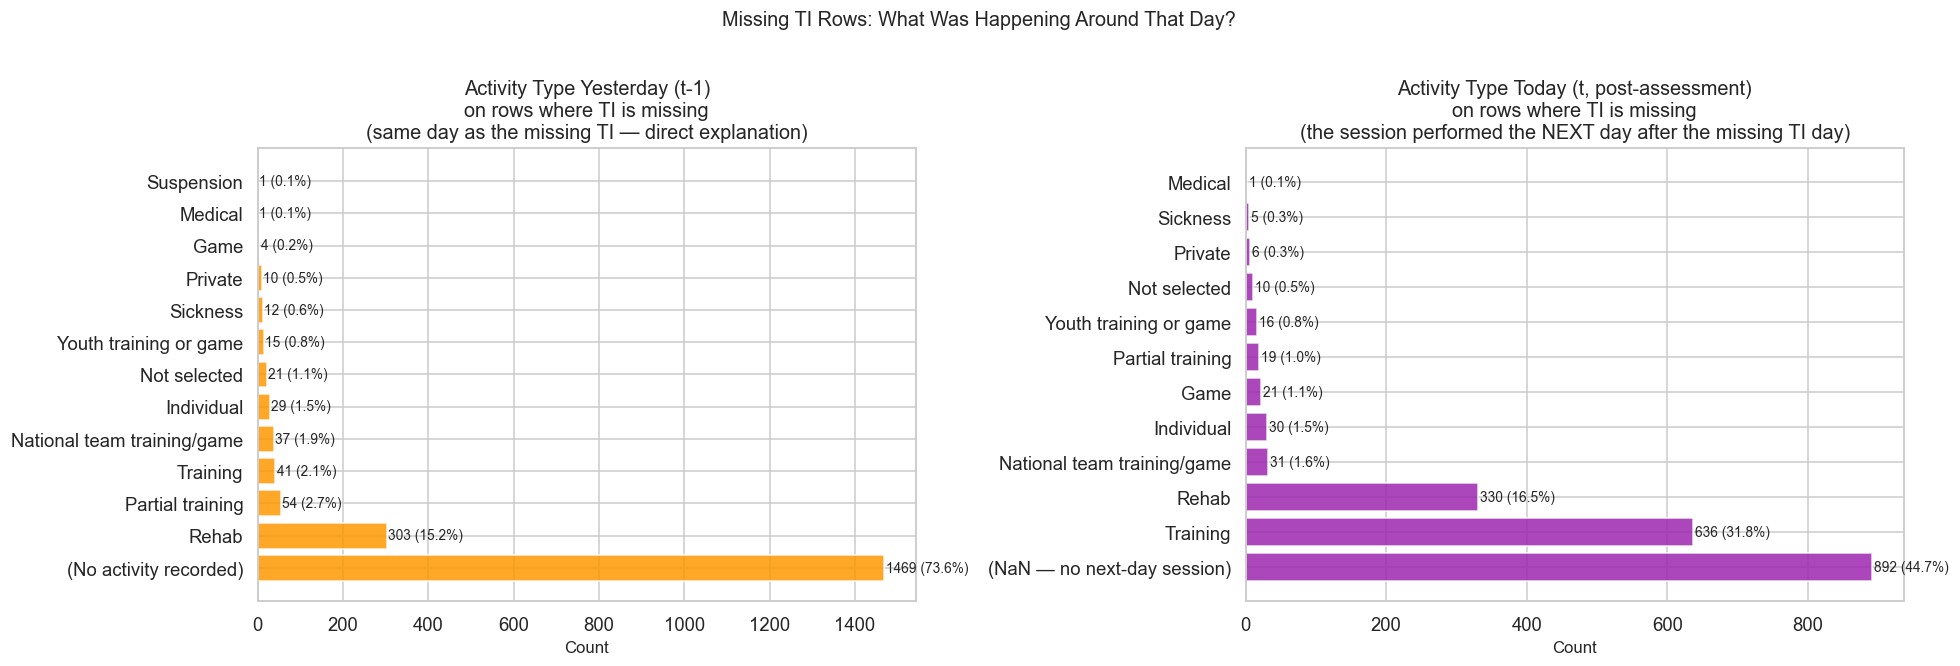

In [4]:
miss_rows = df[ti_missing].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Activity Type Yesterday on missing-TI rows
ax = axes[0]
aty_miss = miss_rows['Activity Type Yesterday'].fillna('(No activity recorded)').value_counts()
bars = ax.barh(aty_miss.index, aty_miss.values, color='#FF9800', edgecolor='white', alpha=0.85)
ax.set_xlabel('Count')
ax.set_title('Activity Type Yesterday (t-1)\non rows where TI is missing\n'
             '(same day as the missing TI — direct explanation)')
for i, v in enumerate(aty_miss.values):
    pct = 100 * v / len(miss_rows)
    ax.text(v + 3, i, f'{v} ({pct:.1f}%)', va='center', fontsize=9)

# Activity Type Today on missing-TI rows
ax = axes[1]
att_miss = miss_rows['Activity Type Today'].fillna('(NaN — no next-day session)').value_counts()
ax.barh(att_miss.index, att_miss.values, color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Count')
ax.set_title('Activity Type Today (t, post-assessment)\non rows where TI is missing\n'
             '(the session performed the NEXT day after the missing TI day)')
for i, v in enumerate(att_miss.values):
    pct = 100 * v / len(miss_rows)
    ax.text(v + 3, i, f'{v} ({pct:.1f}%)', va='center', fontsize=9)

plt.suptitle('Missing TI Rows: What Was Happening Around That Day?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Medical Status and TI Missingness

`Status` is measured on the **morning of day t** — one day after the session that TI Yesterday refers to. A player who is Injured or Absent on day t was likely already unavailable on day t-1, explaining why that day's GPS was not recorded.

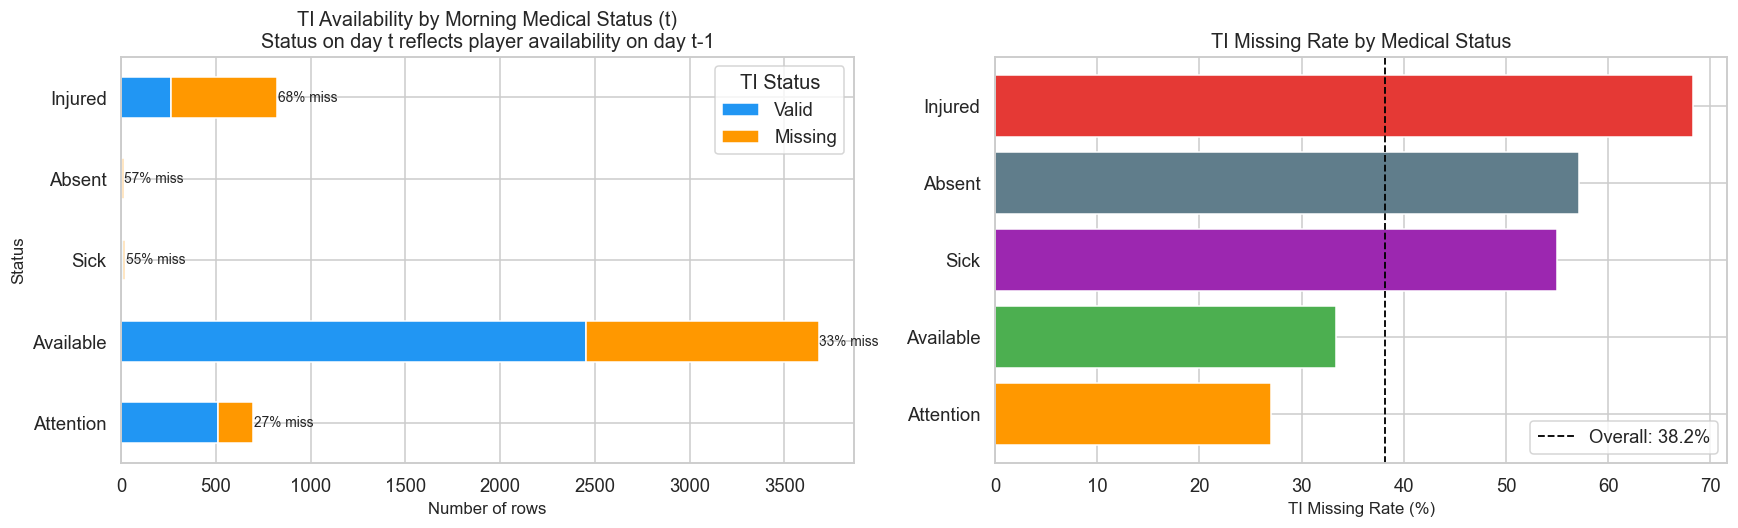

Missing rate by status:
TI Status  Valid  Missing  Missing %
Status                              
Absent         6        8  57.142857
Attention    509      188  26.972740
Available   2452     1229  33.387666
Injured      261      561  68.248175
Sick           9       11  55.000000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar
ax = axes[0]
ct_status = pd.crosstab(df['Status'].fillna('(NaN)'), df['TI Status'])
ct_status = ct_status[['Valid', 'Missing']]
ct_status['Missing %'] = ct_status['Missing'] / ct_status.sum(axis=1) * 100
ct_status_sorted = ct_status.sort_values('Missing %', ascending=True)
ct_status_sorted[['Valid', 'Missing']].plot.barh(
    stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_xlabel('Number of rows')
ax.set_title('TI Availability by Morning Medical Status (t)\n'
             'Status on day t reflects player availability on day t-1')
for i, (idx_name, row) in enumerate(ct_status_sorted.iterrows()):
    total = row['Valid'] + row['Missing']
    ax.text(total + 3, i, f"{row['Missing %']:.0f}% miss", va='center', fontsize=9)

# Missing rate by status
ax = axes[1]
STATUS_COLORS = {'Available':'#4CAF50', 'Attention':'#FF9800',
                 'Injured':'#E53935', 'Sick':'#9C27B0', 'Absent':'#607D8B', '(NaN)':'#999'}
miss_pct = ct_status['Missing %'].sort_values(ascending=True)
ax.barh(miss_pct.index,
        miss_pct.values,
        color=[STATUS_COLORS.get(s, '#999') for s in miss_pct.index],
        edgecolor='white')
ax.axvline(100 * ti_missing.mean(), color='black', linestyle='--',
           linewidth=1.2, label=f'Overall: {100*ti_missing.mean():.1f}%')
ax.set_xlabel('TI Missing Rate (%)')
ax.set_title('TI Missing Rate by Medical Status')
ax.legend()

plt.tight_layout()
plt.show()

print('Missing rate by status:')
print(ct_status[['Valid','Missing','Missing %']].to_string())

## 6. Match Days and Squad Selection

**Match Day** (team-level, morning of t) flags whether the team played an OHL first-team game on day t.  
**Selected** (player-level, post-assessment) flags whether a specific player was in the squad.  

TI Yesterday on a match-day row represents the **pre-match training session** (day t-1 = one day before the match).  
On the day *after* a match (Activity Type Yesterday = 'Game'), TI Yesterday captures the **match GPS load** itself.

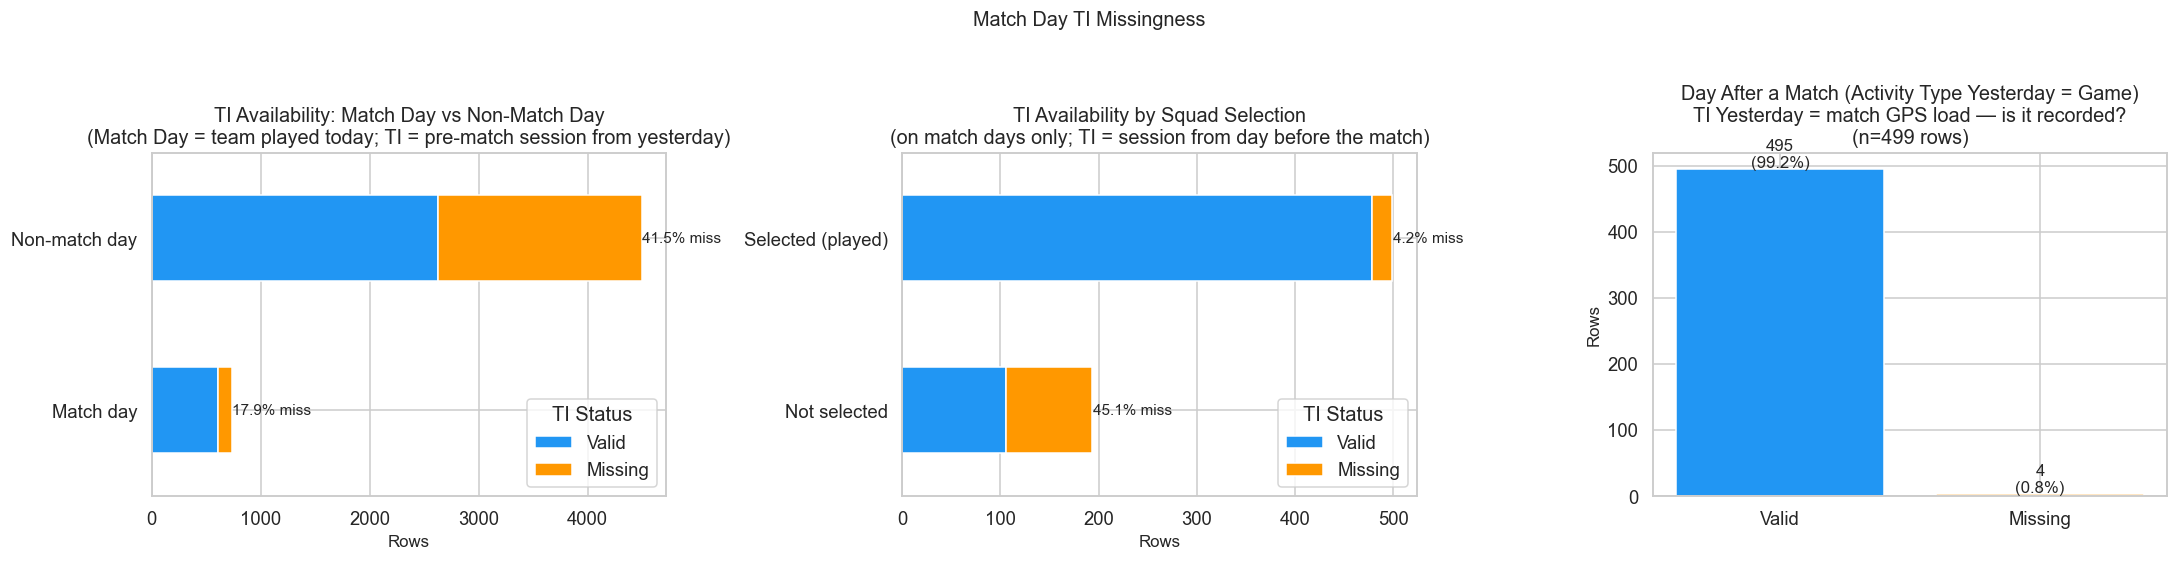

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Match Day
ax = axes[0]
ct_md = pd.crosstab(
    df['Match Day'].fillna(0).astype(int).map({0: 'Non-match day', 1: 'Match day'}),
    df['TI Status']
)[['Valid', 'Missing']]
ct_md.plot.barh(stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_title('TI Availability: Match Day vs Non-Match Day\n'
             '(Match Day = team played today; TI = pre-match session from yesterday)')
ax.set_xlabel('Rows')
ax.set_ylabel('')
for i, (idx_name, row) in enumerate(ct_md.iterrows()):
    total = row.sum()
    ax.text(total + 3, i, f"{row['Missing']/total*100:.1f}% miss", va='center', fontsize=10)

# Selected
ax = axes[1]
sel_df = df[df['Selected'].notna()].copy()
sel_df['Selected Label'] = sel_df['Selected'].map({1.0: 'Selected (played)', 0.0: 'Not selected'})
ct_sel = pd.crosstab(sel_df['Selected Label'], sel_df['TI Status'])[['Valid', 'Missing']]
ct_sel.plot.barh(stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_title('TI Availability by Squad Selection\n'
             '(on match days only; TI = session from day before the match)')
ax.set_xlabel('Rows')
ax.set_ylabel('')
for i, (idx_name, row) in enumerate(ct_sel.iterrows()):
    total = row.sum()
    ax.text(total + 1, i, f"{row['Missing']/total*100:.1f}% miss", va='center', fontsize=10)

# Day after match: TI = match GPS
ax = axes[2]
post_match = df[df['Activity Type Yesterday'] == 'Game'].copy()
vc = post_match['TI Status'].value_counts()
ax.bar(vc.index, vc.values, color=['#2196F3', '#FF9800'], edgecolor='white')
for i, (cat, v) in enumerate(vc.items()):
    ax.text(i, v + 1, f'{v}\n({100*v/len(post_match):.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Rows')
ax.set_title('Day After a Match (Activity Type Yesterday = Game)\n'
             "TI Yesterday = match GPS load — is it recorded?\n"
             f'(n={len(post_match)} rows)')

plt.suptitle('Match Day TI Missingness', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Where in the Match Cycle Is TI Most Often Missing?

Here we use **shifted DUM and DSG** — the cycle position on day t-1 (the session day), not today's morning. This is the correct temporal reference for TI Yesterday.

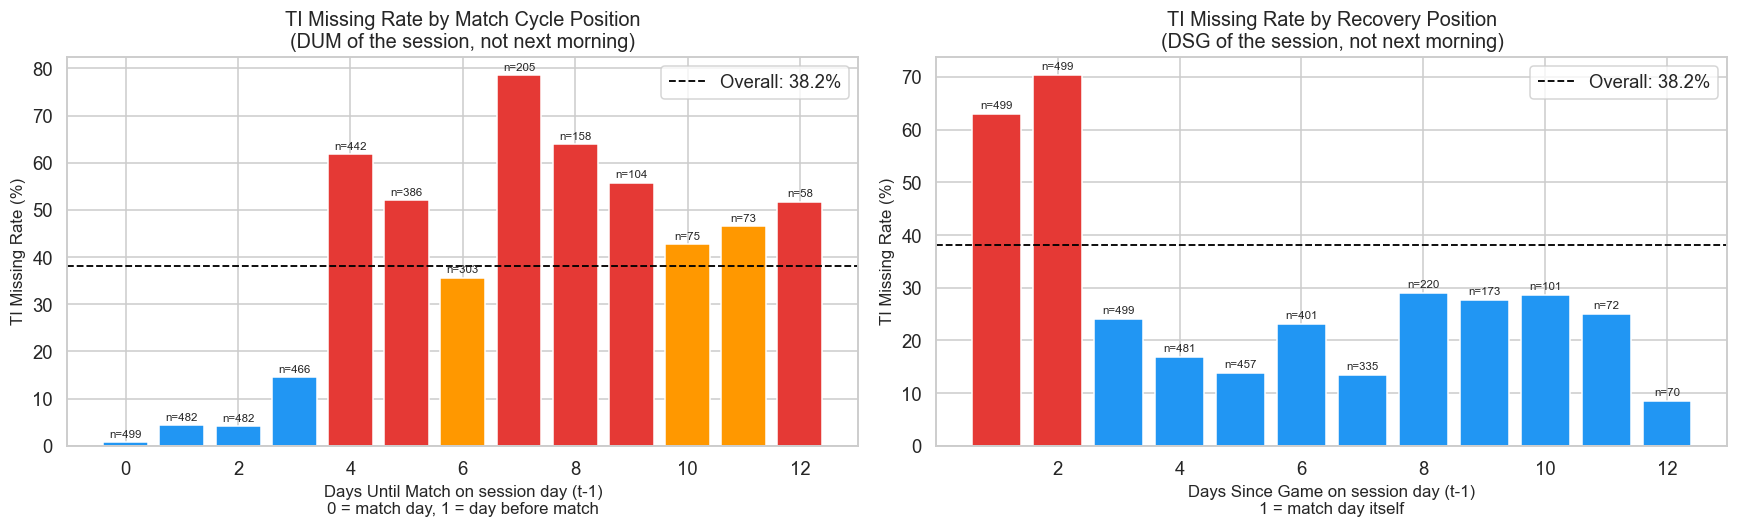

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missing rate by DUM_session
ax = axes[0]
dum_df = df_s.dropna(subset=['DUM_session']).copy()
dum_df['DUM_session_int'] = dum_df['DUM_session'].astype(int)
dum_df = dum_df[dum_df['DUM_session_int'] <= 12]
dum_miss = dum_df.groupby('DUM_session_int')['TI Status'].apply(
    lambda x: (x == 'Missing').mean() * 100)
dum_n = dum_df.groupby('DUM_session_int').size()
bar_colors = ['#E53935' if v > 50 else '#FF9800' if v > 30 else '#2196F3'
              for v in dum_miss.values]
bars = ax.bar(dum_miss.index, dum_miss.values, color=bar_colors, edgecolor='white')
ax.axhline(100 * ti_missing.mean(), color='black', linestyle='--',
           linewidth=1.2, label=f'Overall: {100*ti_missing.mean():.1f}%')
for i, (dum_val, pct) in enumerate(dum_miss.items()):
    ax.text(dum_val, pct + 1, f'n={dum_n[dum_val]}', ha='center', fontsize=7.5)
ax.set_xlabel('Days Until Match on session day (t-1)\n0 = match day, 1 = day before match')
ax.set_ylabel('TI Missing Rate (%)')
ax.set_title('TI Missing Rate by Match Cycle Position\n(DUM of the session, not next morning)')
ax.legend()

# Missing rate by DSG_session
ax = axes[1]
dsg_df = df_s.dropna(subset=['DSG_session']).copy()
dsg_df['DSG_session_int'] = dsg_df['DSG_session'].astype(int)
dsg_df = dsg_df[dsg_df['DSG_session_int'] <= 12]
dsg_miss = dsg_df.groupby('DSG_session_int')['TI Status'].apply(
    lambda x: (x == 'Missing').mean() * 100)
dsg_n = dsg_df.groupby('DSG_session_int').size()
bar_colors2 = ['#E53935' if v > 50 else '#FF9800' if v > 30 else '#2196F3'
               for v in dsg_miss.values]
ax.bar(dsg_miss.index, dsg_miss.values, color=bar_colors2, edgecolor='white')
ax.axhline(100 * ti_missing.mean(), color='black', linestyle='--',
           linewidth=1.2, label=f'Overall: {100*ti_missing.mean():.1f}%')
for i, (dsg_val, pct) in enumerate(dsg_miss.items()):
    ax.text(dsg_val, pct + 1, f'n={dsg_n[dsg_val]}', ha='center', fontsize=7.5)
ax.set_xlabel('Days Since Game on session day (t-1)\n1 = match day itself')
ax.set_ylabel('TI Missing Rate (%)')
ax.set_title('TI Missing Rate by Recovery Position\n(DSG of the session, not next morning)')
ax.legend()

plt.tight_layout()
plt.show()

## 8. Temporal Pattern Across the Season

When are the missing runs concentrated? Long consecutive runs typically indicate injury absence, international duty, or periods before the GPS system was fully deployed.

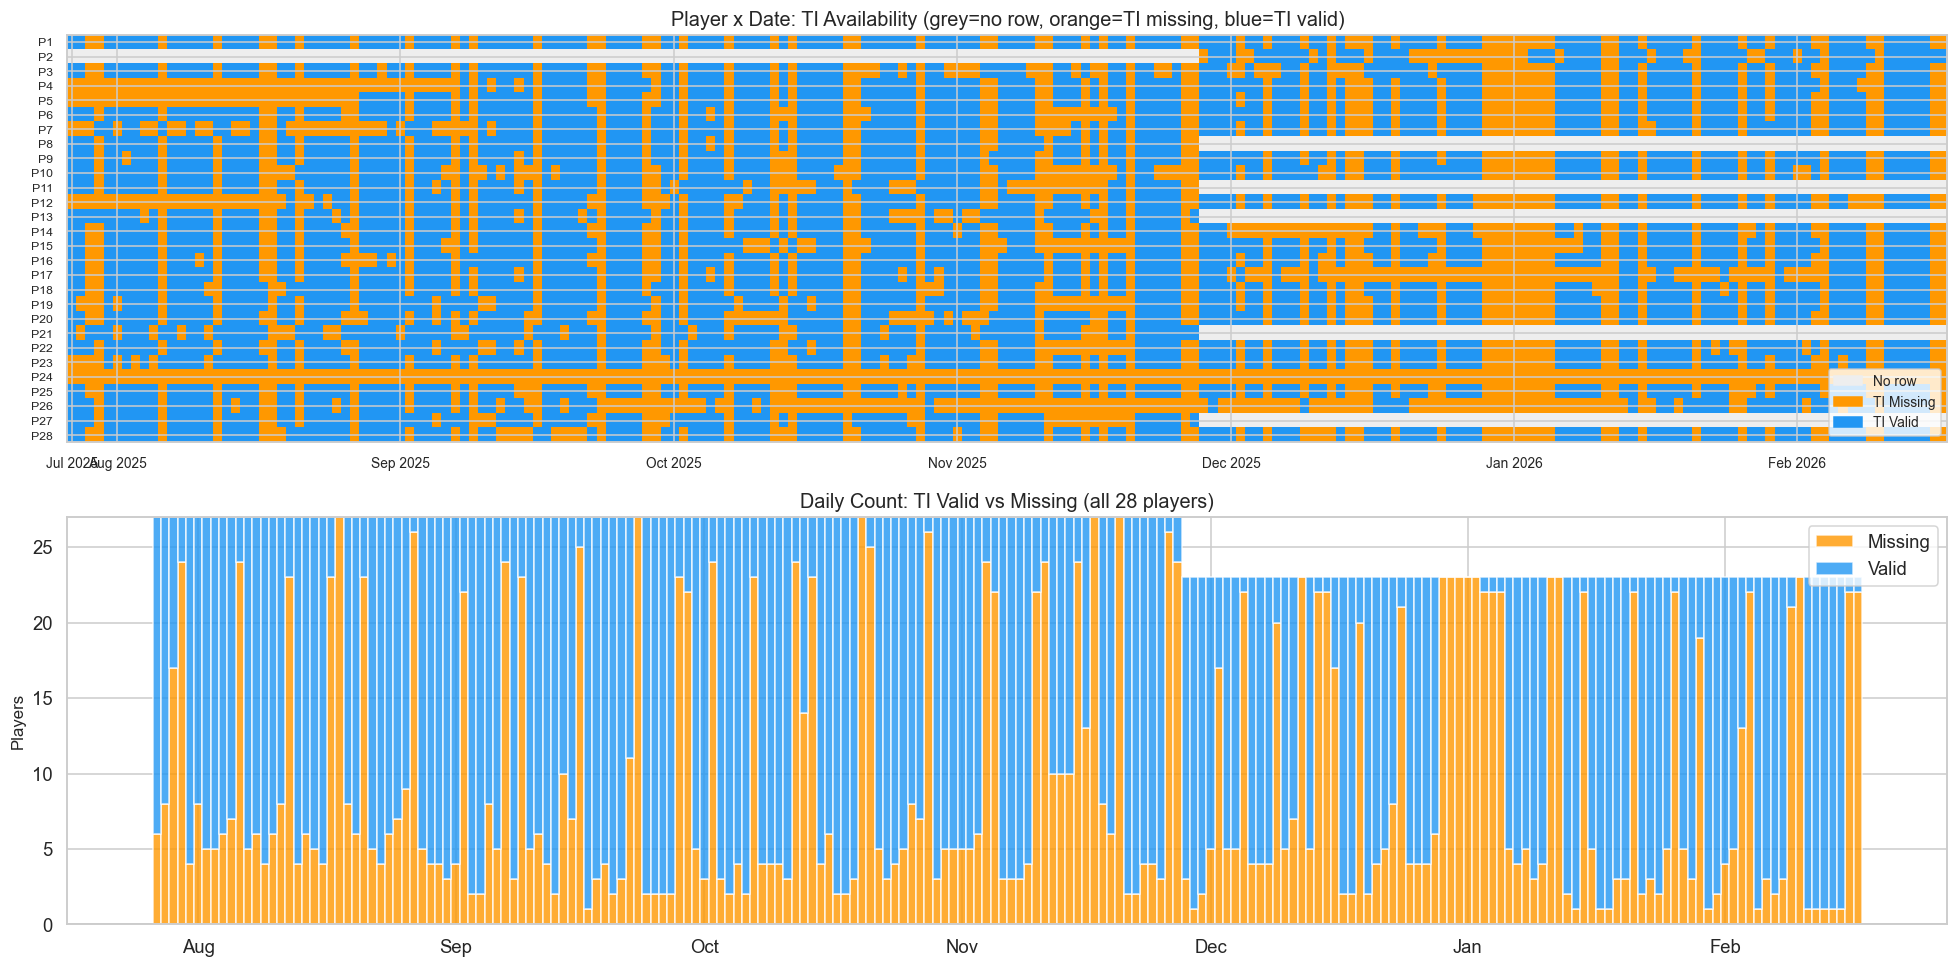

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9))

# Heatmap: player x date, coloured by TI status
ax = axes[0]
players = sorted(df['Player ID'].unique())
dates = sorted(df['Date'].unique())
# 0 = no row, 1 = missing TI, 2 = valid TI
grid = pd.DataFrame(0, index=players, columns=dates)
for _, row in df.iterrows():
    grid.at[row['Player ID'], row['Date']] = 2 if pd.notna(row['Training Intensity Yesterday']) else 1
cmap = plt.cm.colors.ListedColormap(['#EEEEEE', '#FF9800', '#2196F3'])
im = ax.imshow(grid.values, aspect='auto', cmap=cmap, vmin=0, vmax=2,
               interpolation='nearest')
# x-axis: monthly ticks
date_arr = [pd.Timestamp(d) for d in dates]
month_starts = [i for i, d in enumerate(date_arr) if d.day == 1 or i == 0]
ax.set_xticks(month_starts)
ax.set_xticklabels([date_arr[i].strftime('%b %Y') for i in month_starts], fontsize=9)
ax.set_yticks(range(len(players)))
ax.set_yticklabels([f'P{p}' for p in players], fontsize=8)
ax.set_title('Player x Date: TI Availability (grey=no row, orange=TI missing, blue=TI valid)')
legend_patches = [
    mpatches.Patch(color='#EEEEEE', label='No row'),
    mpatches.Patch(color='#FF9800', label='TI Missing'),
    mpatches.Patch(color='#2196F3', label='TI Valid'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

# Daily team-level missing count
ax = axes[1]
daily_miss  = df.groupby('Date').apply(lambda g: (g['Training Intensity Yesterday'].isna()).sum())
daily_valid = df.groupby('Date').apply(lambda g: (g['Training Intensity Yesterday'].notna()).sum())
ax.bar(daily_miss.index, daily_miss.values, color='#FF9800', alpha=0.8, width=1, label='Missing')
ax.bar(daily_valid.index, daily_valid.values, bottom=daily_miss.values,
       color='#2196F3', alpha=0.8, width=1, label='Valid')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel('Players')
ax.set_title('Daily Count: TI Valid vs Missing (all 28 players)')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Player-Level Missingness

Some players have systematically higher missing rates due to long injury absences or periods on international duty. The consecutive-run analysis shows whether missingness comes in long blocks (injury) or scattered single days (non-GPS sessions).

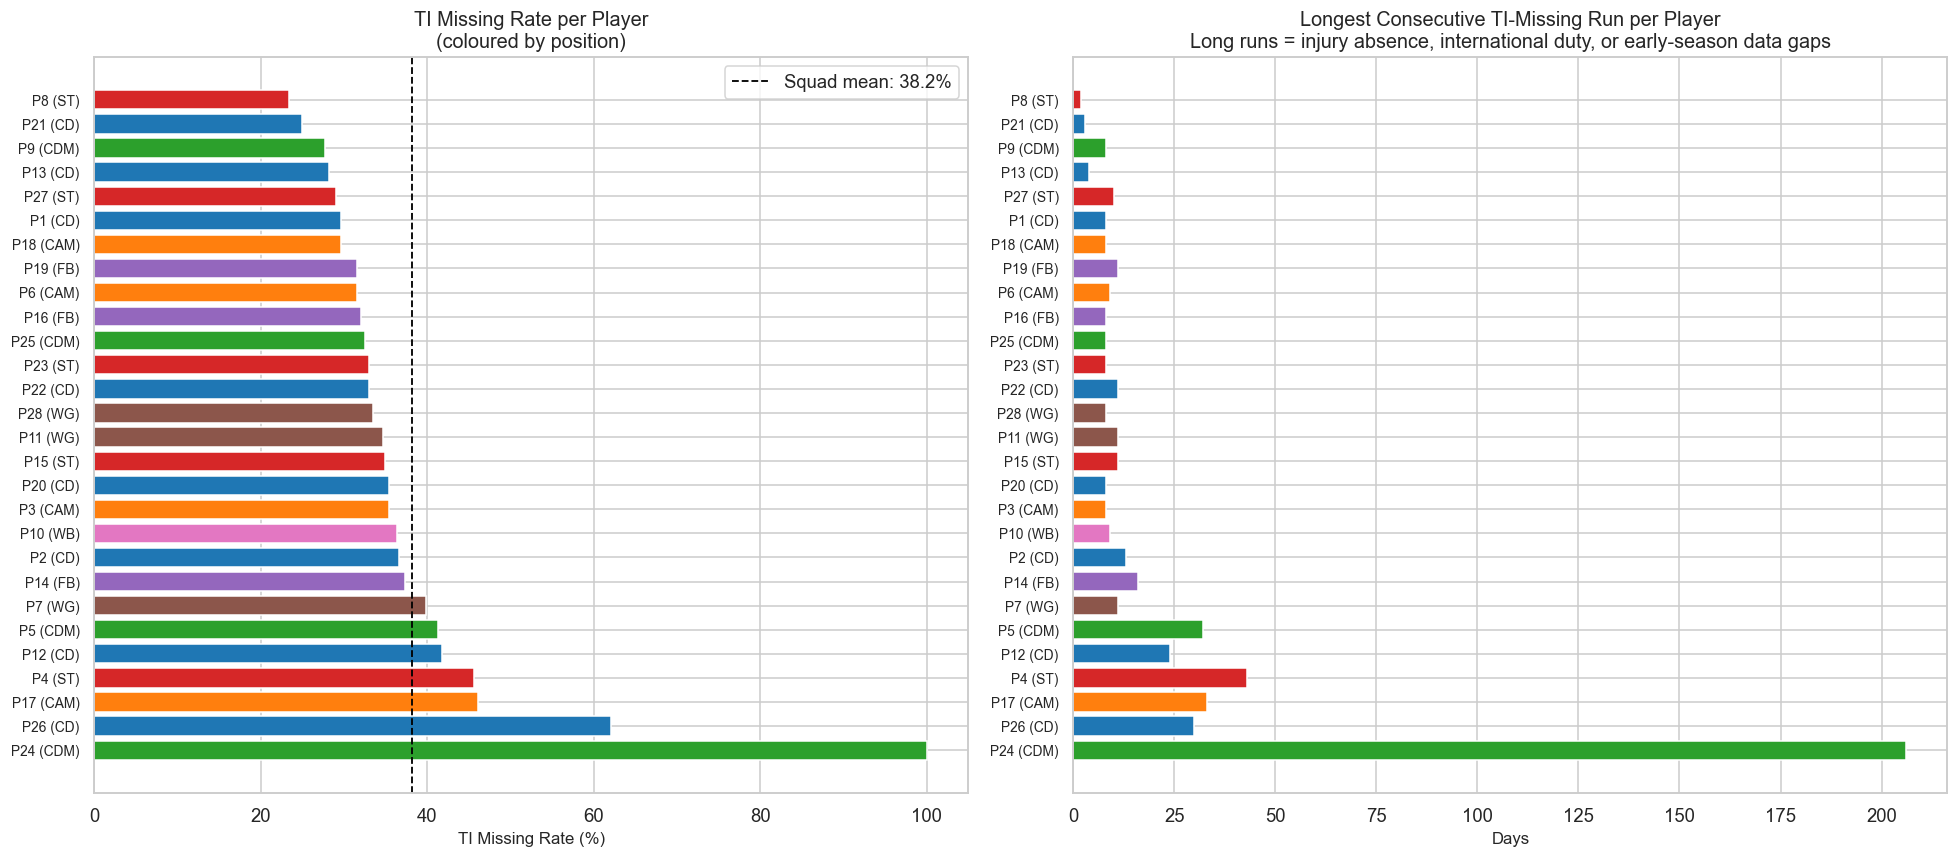

Players with longest missing runs:
            Missing %  Longest run
Player ID                         
24         100.000000          206
26          62.135922           30
17          46.116505           33
4           45.631068           43
12          41.747573           24
5           41.262136           32
7           39.805825           11
14          37.378641           16
2           36.585366           13
10          36.407767            9


In [9]:
import itertools

# Per-player missing rate
player_stats = df.groupby('Player ID').agg(
    Total=('Training Intensity Yesterday', 'count'),  # all rows
    Valid=('Training Intensity Yesterday', 'count'),
).rename(columns={'Valid': 'AllRows'})
player_stats['Valid'] = df.groupby('Player ID')['Training Intensity Yesterday'].apply(
    lambda x: x.notna().sum())
player_stats['Missing'] = df.groupby('Player ID')['Training Intensity Yesterday'].apply(
    lambda x: x.isna().sum())
player_stats['TotalRows'] = player_stats['Valid'] + player_stats['Missing']
player_stats['Missing %'] = player_stats['Missing'] / player_stats['TotalRows'] * 100
player_stats = player_stats.sort_values('Missing %', ascending=False)
player_pos = df.drop_duplicates('Player ID').set_index('Player ID')['Position']

POS_PALETTE = {'CD':'#1f77b4','ST':'#d62728','CDM':'#2ca02c',
               'CAM':'#ff7f0e','FB':'#9467bd','WG':'#8c564b','WB':'#e377c2'}

# Longest consecutive missing run per player
def longest_miss_run(series):
    best = 0
    for key, grp in itertools.groupby(series.isna()):
        if key:
            best = max(best, sum(1 for _ in grp))
    return best

player_stats['Longest run'] = (
    df.sort_values(['Player ID','Date'])
      .groupby('Player ID')['Training Intensity Yesterday']
      .apply(longest_miss_run)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Missing rate
ax = axes[0]
bar_colors = [POS_PALETTE.get(player_pos.get(p,''), '#999') for p in player_stats.index]
ax.barh(range(len(player_stats)), player_stats['Missing %'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(player_stats)))
ax.set_yticklabels([f'P{p} ({player_pos.get(p,"?")})'  for p in player_stats.index], fontsize=9)
ax.axvline(100*ti_missing.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Squad mean: {100*ti_missing.mean():.1f}%')
ax.set_xlabel('TI Missing Rate (%)')
ax.set_title('TI Missing Rate per Player\n(coloured by position)')
ax.legend()

# Longest run
ax = axes[1]
ax.barh(range(len(player_stats)), player_stats['Longest run'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(player_stats)))
ax.set_yticklabels([f'P{p} ({player_pos.get(p,"?")})'  for p in player_stats.index], fontsize=9)
ax.set_xlabel('Days')
ax.set_title('Longest Consecutive TI-Missing Run per Player\n'
             'Long runs = injury absence, international duty, or early-season data gaps')

plt.tight_layout()
plt.show()

print('Players with longest missing runs:')
print(player_stats[['Missing %','Longest run']].head(10).to_string())

## 10. What Else Is Missing at the Same Time?

When TI is missing, how often are other key variables also absent?

- **ACWR columns** come from Readiness\_Data1 GPS metrics — same source as TI.  
- **Raw GPS/HR columns** (Total Minutes Yesterday etc.) come from Raw\_Data.xlsx — a *different* source.  
- **Wellness z-scores** (Fatigue, Readiness, ...) come from morning assessments — independent of GPS.

If Raw GPS is present but TI is still missing, that is a genuine data-quality gap between the two data sources (GPS recorded in Raw\_Data but not in Readiness\_Data1).

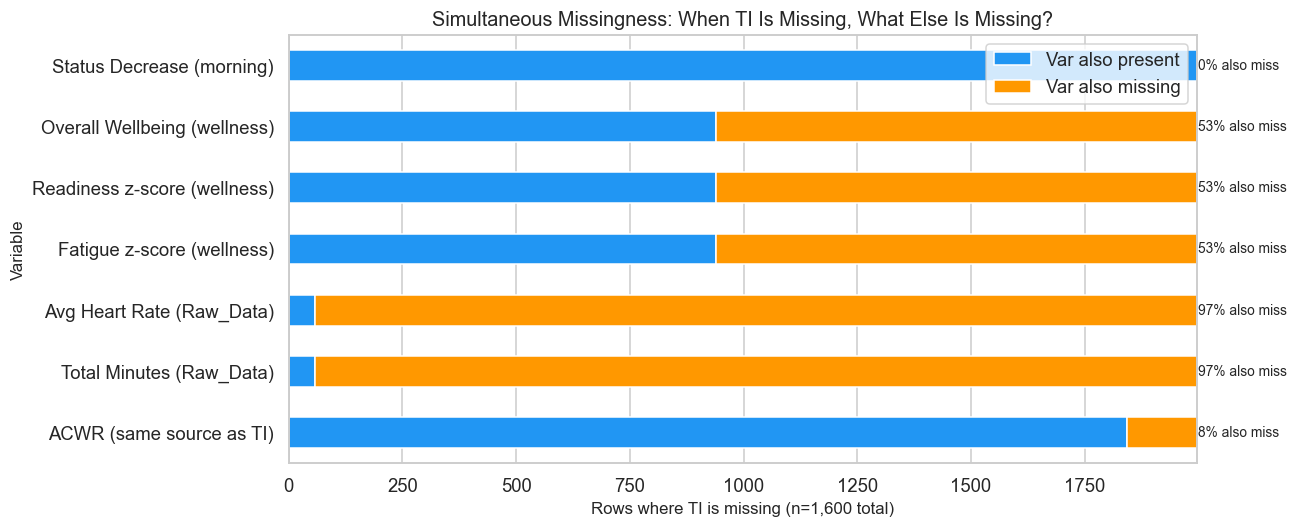

                              TI missing & var missing  TI missing & var present  Pct also missing
Variable                                                                                          
ACWR (same source as TI)                           155                      1842          7.761642
Total Minutes (Raw_Data)                          1940                        57         97.145719
Avg Heart Rate (Raw_Data)                         1940                        57         97.145719
Fatigue z-score (wellness)                        1057                       940         52.929394
Readiness z-score (wellness)                      1057                       940         52.929394
Overall Wellbeing (wellness)                      1057                       940         52.929394
Status Decrease (morning)                            0                      1997          0.000000

Data-quality gap: 57 rows where Raw_Data GPS is present but TI is still missing.
These sessions were recorde

In [10]:
check_cols = {
    'Total Distance (ACWR) Yesterday': 'ACWR (same source as TI)',
    'Total Minutes Yesterday':          'Total Minutes (Raw_Data)',
    'Avg Heart Rate Yesterday':          'Avg Heart Rate (Raw_Data)',
    'Fatigue (z)':                       'Fatigue z-score (wellness)',
    'Readiness (z)':                     'Readiness z-score (wellness)',
    'Overall Wellbeing':                 'Overall Wellbeing (wellness)',
    'Status Decrease':                   'Status Decrease (morning)',
}

rows = []
for col, label in check_cols.items():
    if col not in df.columns:
        continue
    miss_and_col_miss   = (ti_missing &  df[col].isna()).sum()
    miss_and_col_present = (ti_missing & df[col].notna()).sum()
    rows.append({'Variable': label,
                 'TI missing & var missing': miss_and_col_miss,
                 'TI missing & var present': miss_and_col_present,
                 'Pct also missing': 100*miss_and_col_miss/ti_missing.sum()})

simult = pd.DataFrame(rows).set_index('Variable')

fig, ax = plt.subplots(figsize=(12, 5))
simult[['TI missing & var present', 'TI missing & var missing']].plot.barh(
    stacked=True, ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_xlabel('Rows where TI is missing (n=1,600 total)')
ax.set_title('Simultaneous Missingness: When TI Is Missing, What Else Is Missing?')
ax.legend(['Var also present', 'Var also missing'])
for i, (idx_name, row) in enumerate(simult.iterrows()):
    total = row['TI missing & var missing'] + row['TI missing & var present']
    ax.text(total + 3, i,
            f"{row['Pct also missing']:.0f}% also miss",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(simult[['TI missing & var missing','TI missing & var present','Pct also missing']].to_string())

# Flag the data-quality gap
gap = (ti_missing & df['Total Minutes Yesterday'].notna()).sum()
print(f'\nData-quality gap: {gap} rows where Raw_Data GPS is present but TI is still missing.')
print('These sessions were recorded in Raw_Data.xlsx but GPS% not filled in Readiness_Data.')

## 11. Profile of Missing vs Valid Rows

Do rows with missing TI look different in terms of wellness, ACWR, and medical status?  

**Temporal note:** Wellness z-scores and Status are morning-of-t variables; TI Yesterday is t-1. The comparison is valid: it asks whether the next-morning wellness state differs depending on whether the previous day's GPS was recorded.

C:\Users\U0152019\AppData\Local\Temp\ipykernel_22880\1964302275.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v_data, m_data], labels=['TI Valid', 'TI Missing'],
C:\Users\U0152019\AppData\Local\Temp\ipykernel_22880\1964302275.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot([v_data, m_data], labels=['TI Valid', 'TI Missing'],
C:\Users\U0152019\AppData\Local\Temp\ipykernel_22880\1964302275.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v_data, m_data], labels=['TI Valid', 'TI Missing'],
C:\Users\U0152019\AppData\Local\Temp\ipykernel_22880\1964302275.py:38: Mat

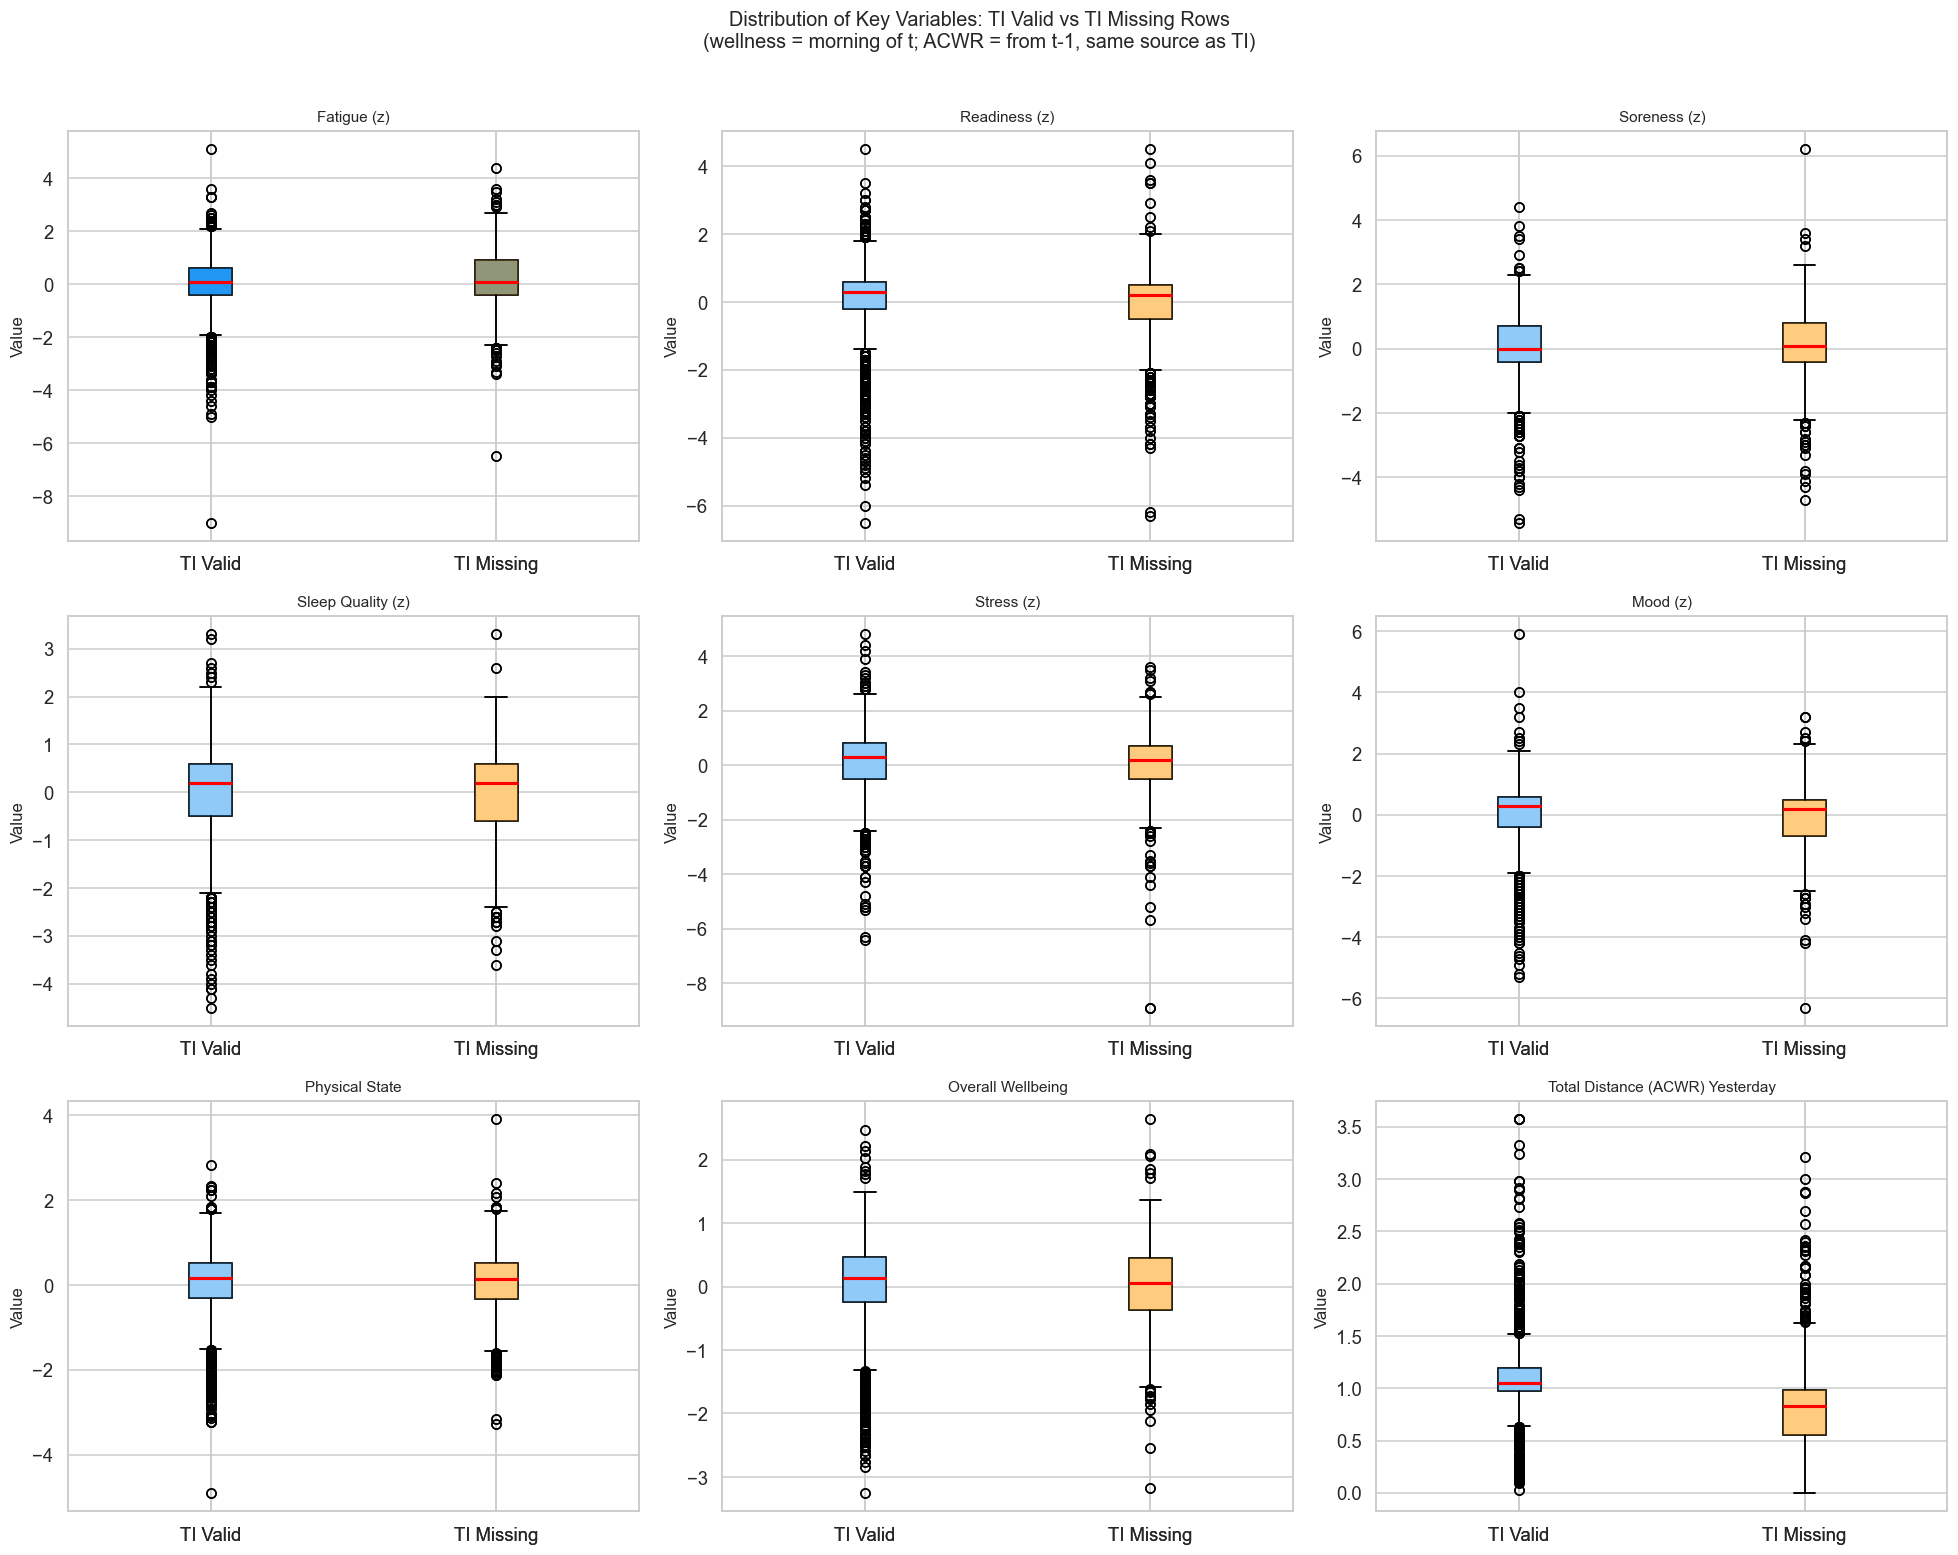

Mean comparison (missing TI rows vs valid TI rows):
                                 Mean (valid TI)  Mean (missing TI)   Diff  N valid  N missing
Variable                                                                                      
Fatigue (z)                                0.018              0.092  0.074     1771        940
Readiness (z)                              0.052             -0.058 -0.110     1771        940
Soreness (z)                               0.045              0.087  0.042     1771        940
Sleep Quality (z)                         -0.003             -0.047 -0.044     1771        940
Stress (z)                                 0.063             -0.016 -0.079     1771        940
Mood (z)                                  -0.020             -0.068 -0.048     1771        940
Physical State                             0.039              0.040  0.002     1771        940
Overall Wellbeing                          0.026             -0.002 -0.027     1771        94

In [11]:
compare_cols = [
    'Fatigue (z)', 'Readiness (z)', 'Soreness (z)',
    'Sleep Quality (z)', 'Stress (z)', 'Mood (z)',
    'Physical State', 'Overall Wellbeing',
    'Total Distance (ACWR) Yesterday',
]

summary_rows = []
for col in compare_cols:
    if col not in df.columns:
        continue
    v_vals = df.loc[ti_valid, col].dropna()
    m_vals = df.loc[ti_missing, col].dropna()
    summary_rows.append({
        'Variable': col,
        'Mean (valid TI)':   v_vals.mean(),
        'Mean (missing TI)': m_vals.mean(),
        'Diff':              m_vals.mean() - v_vals.mean(),
        'N valid':   len(v_vals),
        'N missing': len(m_vals),
    })

profile_df = pd.DataFrame(summary_rows).set_index('Variable')

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    if col not in df.columns or i >= len(axes):
        continue
    ax = axes[i]
    v_data = df.loc[ti_valid, col].dropna()
    m_data = df.loc[ti_missing, col].dropna()
    ax.boxplot([v_data, m_data], labels=['TI Valid', 'TI Missing'],
               patch_artist=True,
               boxprops=dict(facecolor='#2196F3' if i < 1 else 'white'),
               medianprops=dict(color='red', linewidth=2))
    bplot = ax.boxplot([v_data, m_data], labels=['TI Valid', 'TI Missing'],
                        patch_artist=True, medianprops=dict(color='red', linewidth=2))
    bplot['boxes'][0].set_facecolor('#2196F3')
    bplot['boxes'][0].set_alpha(0.5)
    bplot['boxes'][1].set_facecolor('#FF9800')
    bplot['boxes'][1].set_alpha(0.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Variables: TI Valid vs TI Missing Rows\n'
             '(wellness = morning of t; ACWR = from t-1, same source as TI)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print('Mean comparison (missing TI rows vs valid TI rows):')
print(profile_df[['Mean (valid TI)','Mean (missing TI)','Diff','N valid','N missing']].round(3).to_string())

## 12. Data-Quality Gap: Raw GPS Present but TI Missing

In 79 rows, `Total Minutes Yesterday` is present (session recorded in Raw\_Data.xlsx) but `Training Intensity Yesterday` is missing (GPS% not in Readiness\_Data1.xlsx).  

These are sessions where a player clearly participated but the GPS benchmark percentage columns were not populated in the readiness tracking system. Understanding which activity types and players these belong to helps assess whether this gap is systematic.

Gap rows: 57 (Raw GPS present, TI missing)


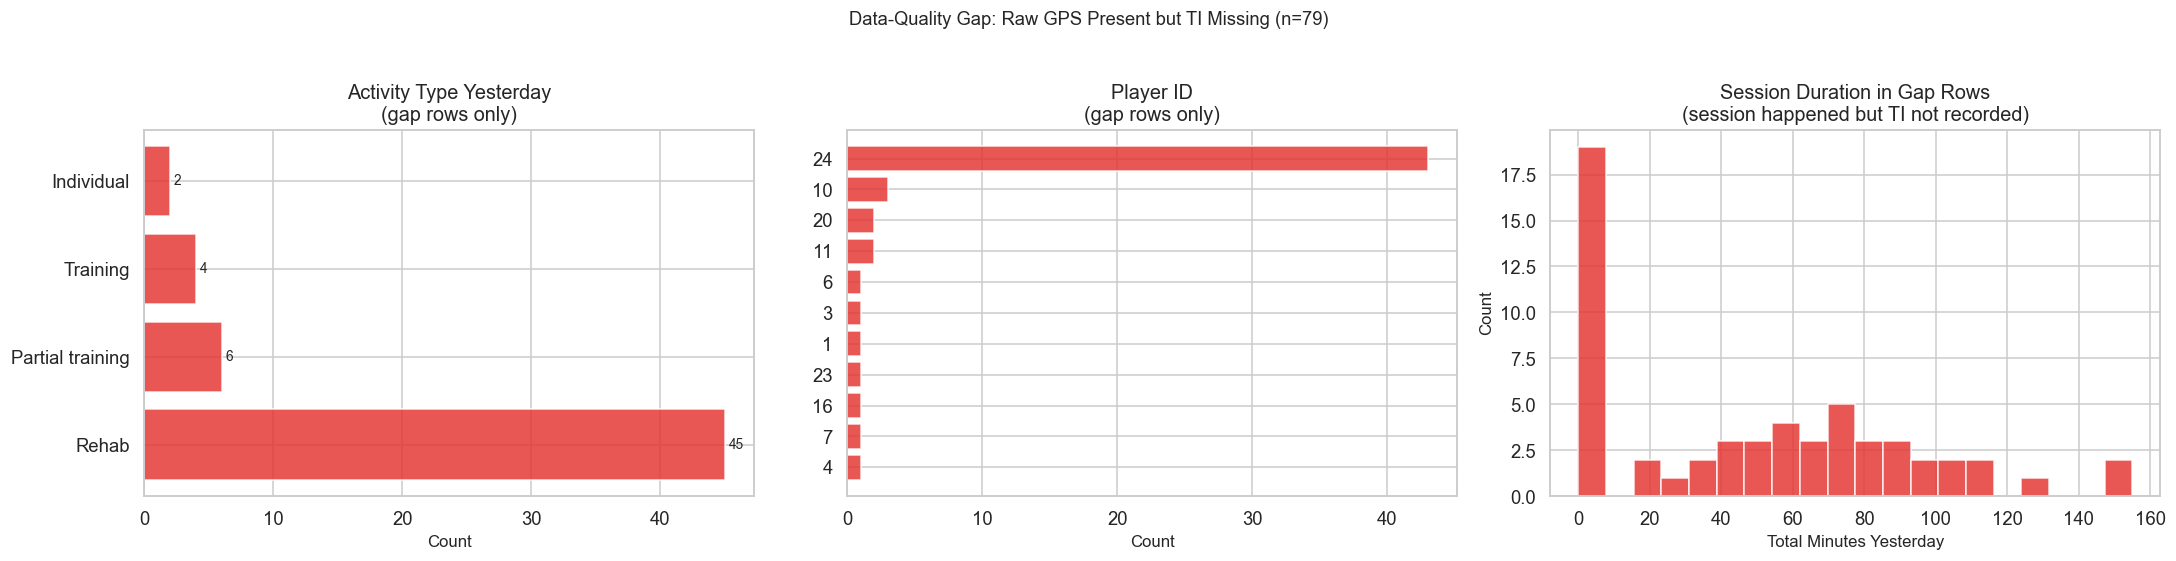


Activity type breakdown in gap rows:
Activity Type Yesterday
Rehab               45
Partial training     6
Training             4
Individual           2

Total Minutes range: 0 – 155 min


In [12]:
gap_rows = df[(ti_missing) & (df['Total Minutes Yesterday'].notna())].copy()
print(f'Gap rows: {len(gap_rows)} (Raw GPS present, TI missing)')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# By Activity Type Yesterday
ax = axes[0]
vc = gap_rows['Activity Type Yesterday'].fillna('(NaN)').value_counts()
ax.barh(vc.index, vc.values, color='#E53935', edgecolor='white', alpha=0.85)
ax.set_xlabel('Count')
ax.set_title('Activity Type Yesterday\n(gap rows only)')
for i, v in enumerate(vc.values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

# By Player
ax = axes[1]
vc_p = gap_rows['Player ID'].value_counts().sort_values(ascending=True)
ax.barh(vc_p.index.astype(str), vc_p.values, color='#E53935', edgecolor='white', alpha=0.85)
ax.set_xlabel('Count')
ax.set_title('Player ID\n(gap rows only)')

# Distribution of Total Minutes in gap rows
ax = axes[2]
ax.hist(gap_rows['Total Minutes Yesterday'].dropna(), bins=20,
        color='#E53935', edgecolor='white', alpha=0.85)
ax.set_xlabel('Total Minutes Yesterday')
ax.set_ylabel('Count')
ax.set_title('Session Duration in Gap Rows\n(session happened but TI not recorded)')

plt.suptitle('Data-Quality Gap: Raw GPS Present but TI Missing (n=79)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\nActivity type breakdown in gap rows:')
print(gap_rows['Activity Type Yesterday'].value_counts(dropna=False).to_string())
print(f'\nTotal Minutes range: {gap_rows["Total Minutes Yesterday"].min():.0f} – '
      f'{gap_rows["Total Minutes Yesterday"].max():.0f} min')

## 13. Summary

| Finding | Detail |
|---|---|
| **Overall missingness** | 37.7 % of all player-days (1,600 / 14,359 rows) |
| **Primary cause** | No activity recorded in Readiness_Data on day t-1 (73 % of missing cases) |
| **Training sessions** | Only 3.8 % missing when Activity Type Yesterday = Training |
| **Rehab sessions** | 67 % missing — GPS benchmarks not collected for rehabilitation |
| **Injured players** | 71 % missing — injured players do not perform tracked GPS sessions |
| **Match days** | 18.7 % missing (lower than average — selected players always have pre-match GPS) |
| **Selected players** | Only 1.3 % missing on match days (pre-match training is always tracked) |
| **Day after match** | 5.9 % missing — match GPS load is almost always recorded |
| **Long missing runs** | One player has a 157-day gap (season-ending injury); most runs are 1–2 days |
| **Data-quality gap** | 79 rows where Raw_Data GPS is present but TI is still missing |
| **Wellness when missing** | Substantially lower (more fatigue, lower readiness) — driven by injured/absent player profiles, not by the missingness mechanism itself |

**Implication for modelling:** TI is Missing Not At Random (MNAR). Rows without TI disproportionately represent injured, absent, or rehabbing players. Imputing TI for these rows with the mean would be incorrect. They should either be excluded from training-load analyses or handled with a dedicated missingness indicator.